# Построение статистик 
Здесь представлены изображения и прилагаемый код к визуализациям подробным распределения выборок.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/home/user/papkamusik/action_folder/features_177_updated.csv")
df

In [13]:
df = df.drop(columns=["f0_slope", "f1_slope","f2_slope","f3_slope"])

# Таблица корреляций
Построение корреляции для выявления наиболее скоррелированных признаков (0.7). В случае обнаружения таких признаков удаления их с обязательным указанием ниже.

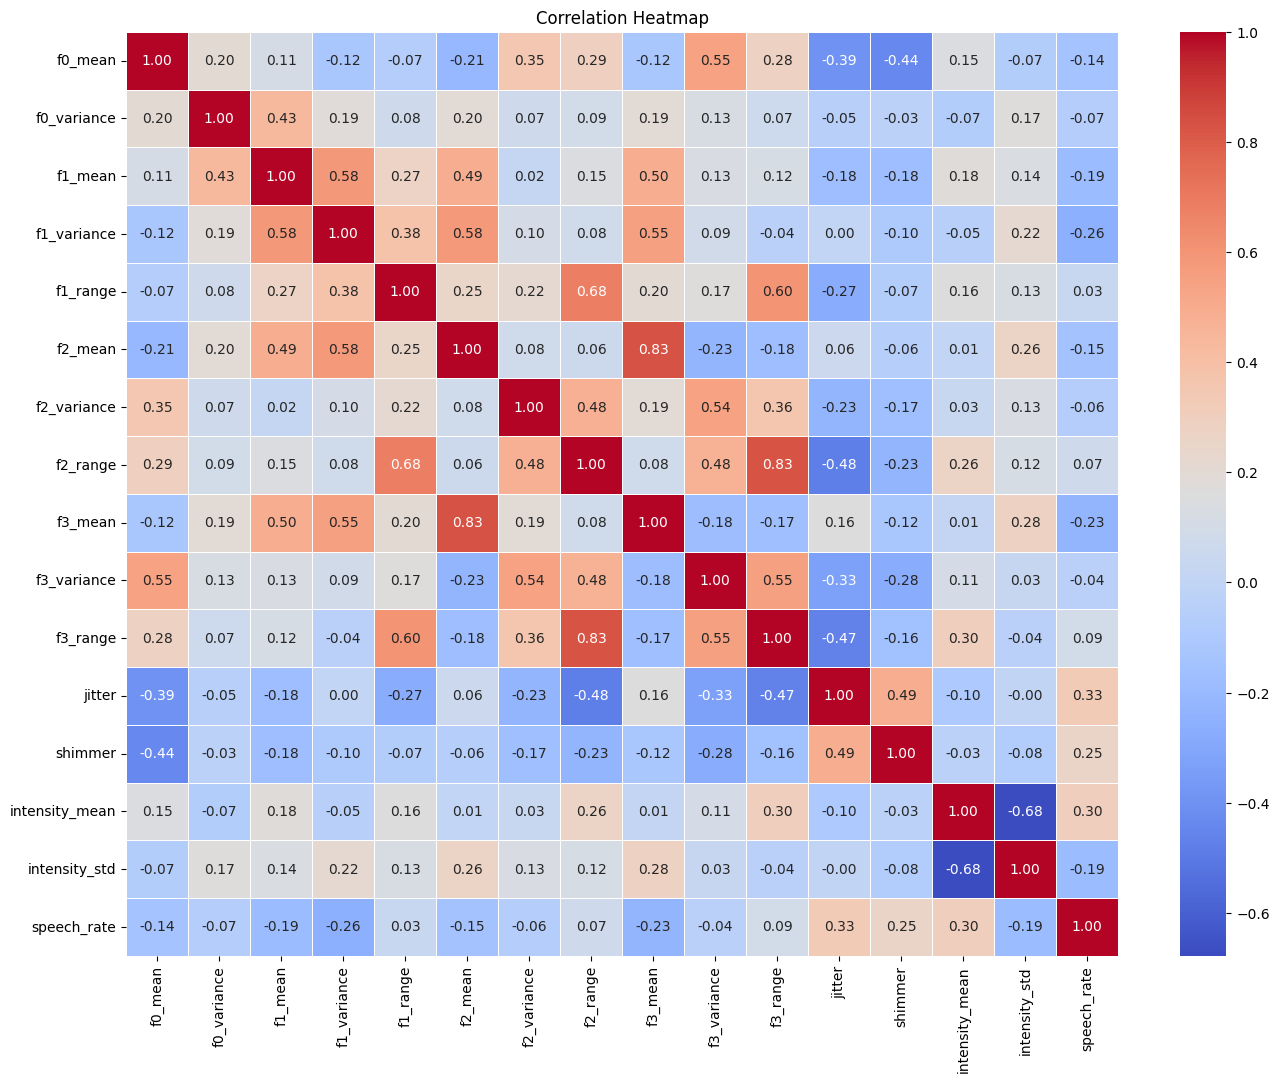

In [ ]:
df_numeric = df.select_dtypes(include=['number'])
corr = df_numeric.corr()

russian_labels = [УКАЖИТЕ_ПО_ПОРЯДКУ]

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    xticklabels=russian_labels,
    yticklabels=russian_labels
)
plt.title('Таблица корреляций признаков')
plt.show()

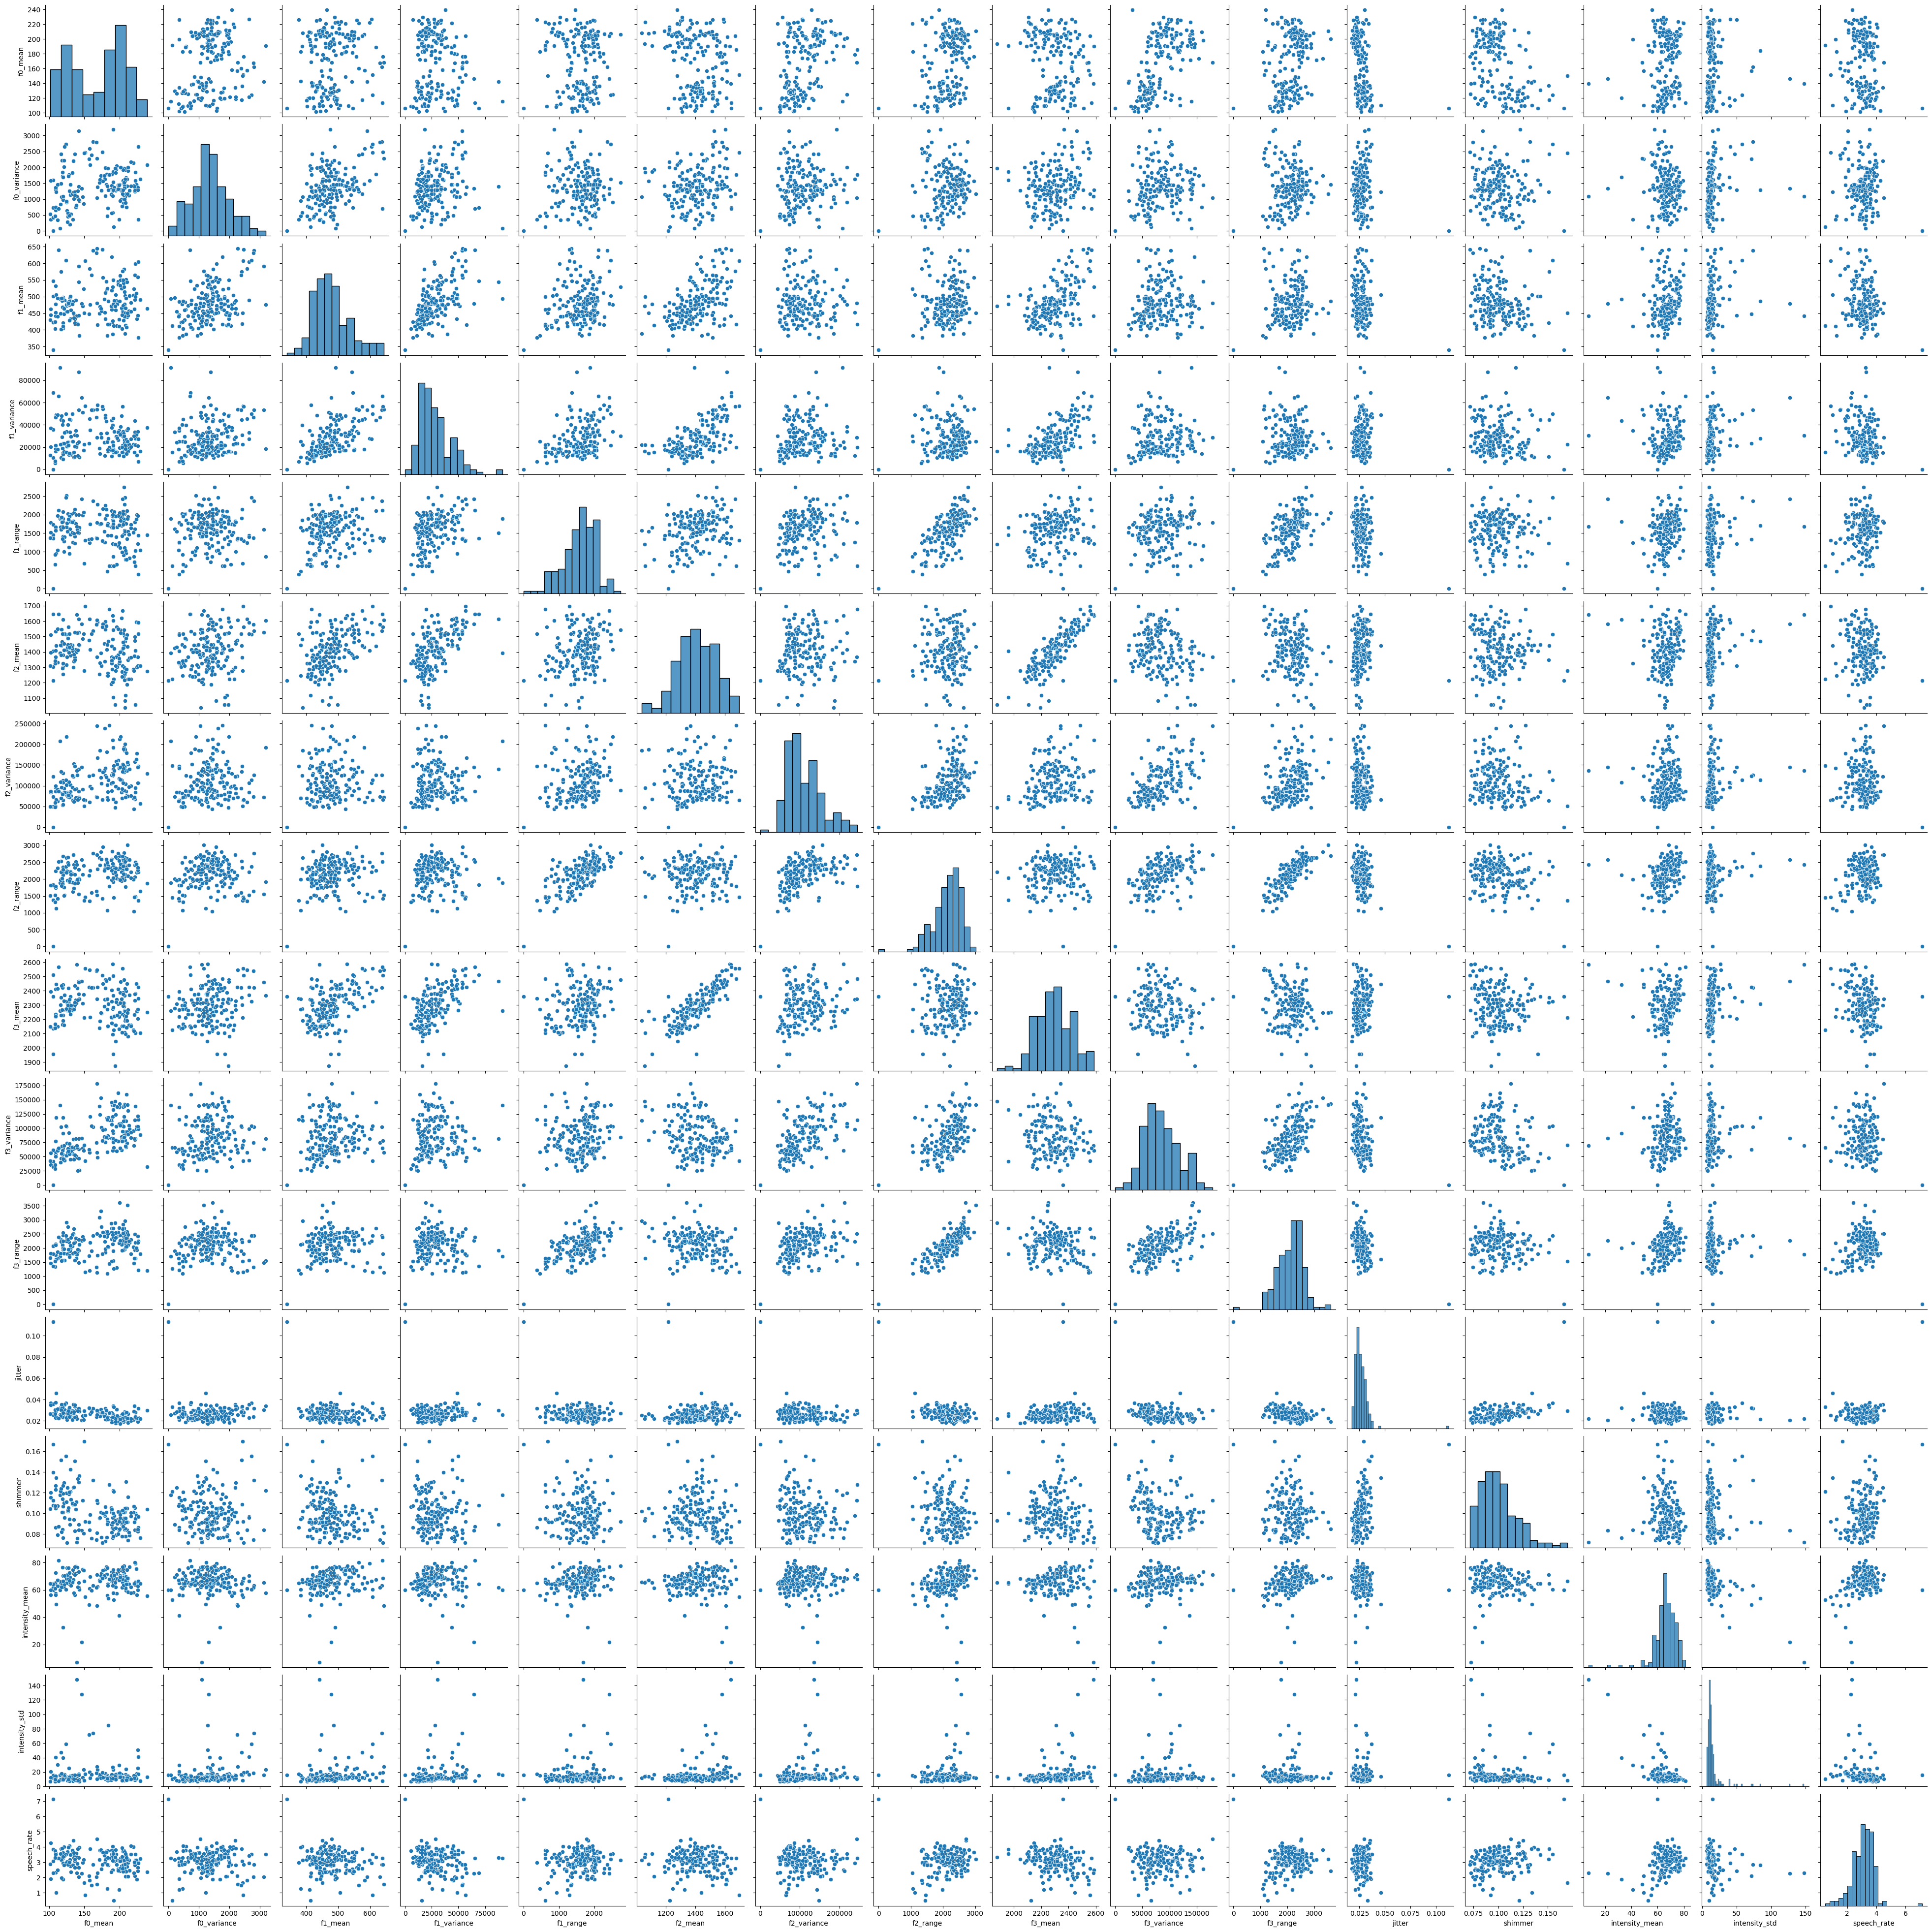

In [ ]:
df_numeric = df.select_dtypes(include=['number'])

# Создаём сетку
g = sns.PairGrid(df_numeric, diag_sharey=False)

# Верхний треугольник — пустой
g.map_upper(plt.scatter, alpha=0)   # или g.map_upper(lambda *args, **kwargs: None)

# Диагональ — гистограммы или kde
g.map_diag(sns.histplot, kde=True)

# Нижний треугольник — scatter plot с настройками
g.map_lower(sns.scatterplot, alpha=0.4, s=15, edgecolor='none')


plt.show()

In [20]:
df

,Unnamed: 0,call_id,role,total_duration,f0_mean,f0_median,f0_variance,f0_std,f0_min,f0_max,...,spectral_flatness_min,spectral_flatness_max,spectral_flatness_range,spectral_flatness_skew,spectral_flatness_kurtosis,spectral_flatness_cv,duration_group,gender,age,age_group
0,0,6dd09bb55ea0f2b363323075ebd80891,user,96.639,160.296460,157.185579,1675.346531,40.930997,74.967251,299.948467,...,4.532922e-07,0.023119,0.023119,8.940519,107.470968,2.684108,1.5-2min,Male,54.0,50-60 y.o
1,2,7c749f781537e584be74e1c6231bc0d7,user,48.640,200.123394,200.632542,1470.666892,38.349275,74.967567,299.945509,...,2.656452e-07,0.034895,0.034894,12.991871,220.951054,2.923322,40-50s,Female,40.0,40-50 y.o
2,3,4f331c8df6c7daf200725fee910669c7,user,66.580,201.507328,199.463008,1525.067940,39.052118,74.947810,299.798429,...,7.132432e-07,0.023383,0.023382,6.398229,56.406650,2.549637,1-1.5min,Female,50.0,50-60 y.o
3,4,be754baf8e32c3cbf0d7c704332baa8d,user,133.540,210.380713,209.920131,1666.750450,40.825855,75.061698,299.860337,...,4.355283e-07,0.029109,0.029108,10.257932,137.638885,3.127183,2-3min,Male,48.0,40-50 y.o
4,5,b2934e30184a1f8ab4ef3c336730feef,user,62.141,223.552908,223.626064,1293.551901,35.965983,77.497462,299.981354,...,4.703544e-07,0.041866,0.041866,12.842789,222.104988,2.588607,1-1.5min,Female,30.0,30-40 y.o
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,540,c0f45db39d7c607598b57fbae8c8d0c6,user,54.860,141.832459,136.774154,837.387153,28.937642,75.257341,275.289250,...,1.992328e-06,0.047694,0.047692,9.240815,102.884789,3.690126,50-60s,Male,61.0,60-70 y.o
396,541,618acac51fe576c7cf7891bc2a15a4a9,user,73.519,206.384069,202.403295,1444.051724,38.000681,75.866949,299.840799,...,8.332757e-07,1.000000,0.999999,4.962287,22.649889,4.964676,1-1.5min,Male,39.0,30-40 y.o
397,542,942bcd5d9aa456ffe71e6876158ec9e2,user,54.079,182.565872,182.479290,1328.687454,36.451165,74.950293,298.334976,...,4.847070e-07,0.044532,0.044532,13.328122,261.255785,4.122211,50-60s,Female,61.0,60-70 y.o
398,543,6b3c5465fce56be39e3a61be55bd3bc0,user,36.780,227.964270,232.747192,1389.948327,37.282011,87.066962,299.924789,...,2.022659e-06,0.115210,0.115208,11.567612,144.758252,3.363312,30-40s,Male,20.0,18-25 y.o


/tmp/ipykernel_30801/3025082054.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["duration_group", "gender"]).size().reset_index(name="count")


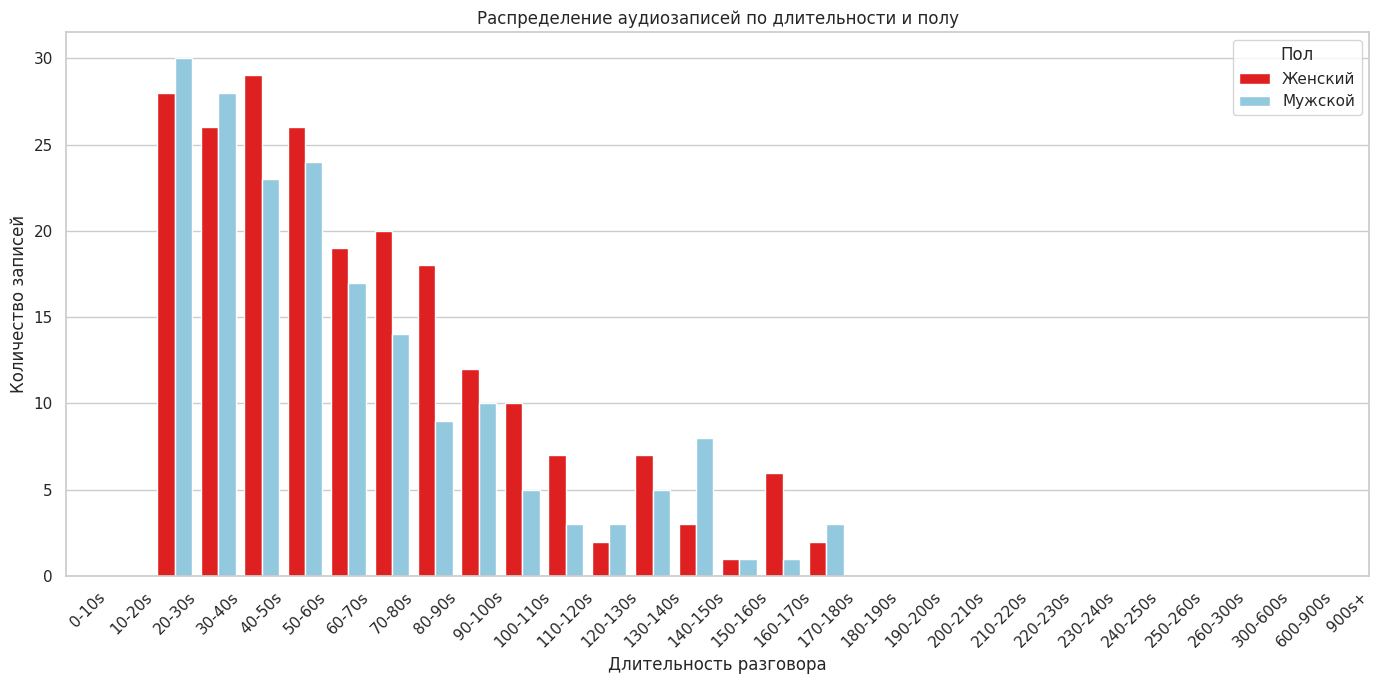

In [ ]:


sns.set(style="whitegrid")

df = pd.read_csv("/home/user/papkamusik/action_folder/filtered_resulted_100.csv")
df = df.dropna()
df["gender"] = df["gender"].str.lower()


bins = [
    0, 10, 20, 30, 40, 50, 60, 70, 80, 90,
    100, 110, 120, 130, 140 ,150, 160, 170,
    180, 190, 200, 210,220,230,240, 250,260,
    300, 600, 900, float('inf')
]
labels = [
    "0-10s", "10-20s", "20-30s", "30-40s", "40-50s",
    "50-60s", "60-70s", "70-80s", "80-90s", "90-100s",
    "100-110s", "110-120s", "120-130s", "130-140s", "140-150s",
    "150-160s", "160-170s", "170-180s", "180-190s", "190-200s",
    "200-210s", "210-220s", "220-230s", "230-240s", "240-250s",
    "250-260s", "260-300s", "300-600s", "600-900s", "900s+"
]

# создаём duration_group НА ВСЁМ df
df["duration_group"] = pd.cut(df["total_duration"], bins=bins, labels=labels, right=False)

# считаем сразу с группировкой
counts = df.groupby(["duration_group", "gender"]).size().reset_index(name="count")


# строим график
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=counts,
    x="duration_group",
    y="count",
    hue="gender",
    palette={"female": "red", "male": "skyblue"}
)


plt.title("Количество аудиозаписей по времени разговора по группам и полу")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)

plt.title("Распределение аудиозаписей по длительности и полу")
plt.xlabel("Длительность разговора")   # ✔ ИСПРАВЛЕНО
plt.ylabel("Количество записей")
plt.xticks(rotation=45)

# легенда
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, ["Женский", "Мужской"], title="Пол")

plt.tight_layout()
plt.show()

/tmp/ipykernel_30801/1961918400.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(["age_group", "gender"]).size().reset_index(name="count")


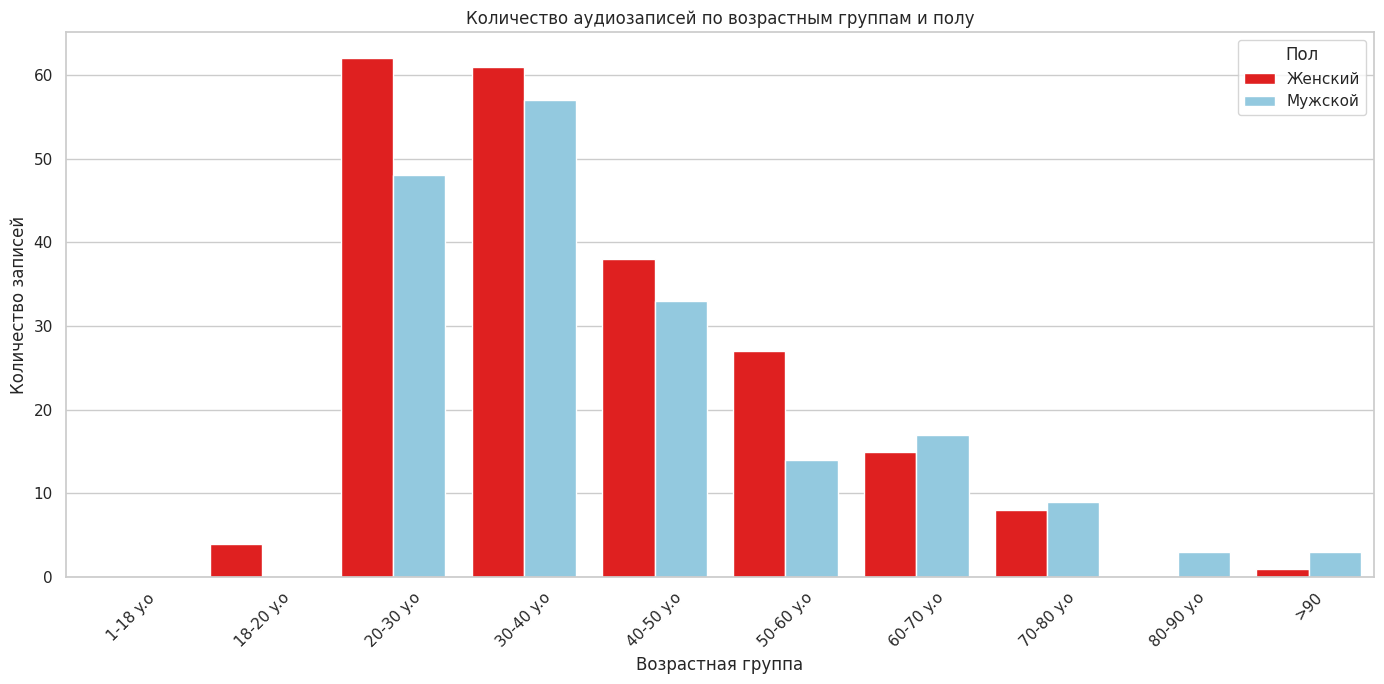

In [ ]:

sns.set(style="whitegrid")

df = pd.read_csv("/home/user/papkamusik/action_folder/filtered_resulted_100.csv")
df = df.dropna()
df["gender"] = df["gender"].str.lower()

bins = [
    1, 18, 20, 30, 40, 50, 60, 70, 80, 90, float('inf')
]
labels = [      
    "1-18 y.o", "18-20 y.o", "20-30 y.o", "30-40 y.o", "40-50 y.o",
    "50-60 y.o", "60-70 y.o", "70-80 y.o", "80-90 y.o", ">90"
]

# создаём age_group НА ВСЁМ df
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels, right=False)

# считаем сразу с группировкой
counts = df.groupby(["age_group", "gender"]).size().reset_index(name="count")

# строим график
plt.figure(figsize=(14, 7))

ax = sns.barplot(
    data=counts,
    x="age_group",
    y="count",
    hue="gender",
    palette={"female": "red", "male": "skyblue"}
)

plt.title("Количество аудиозаписей по возрастным группам и полу")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество записей")
plt.xticks(rotation=45)


# меняем название легенды и подписи
handles, labels = ax.get_legend_handles_labels()

ax.legend(handles, ["Женский", "Мужской"], title="Пол")

plt.tight_layout()
plt.show()

In [33]:
print(len(df))
df = df[df["age_group"] != "1-18 y.o"]
df = df[df["age_group"] != "80-90 y.o"]
df = df[df["age_group"] != ">90"]

print(len(df))


400
393


/tmp/ipykernel_30801/14598605.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = df.groupby(["age_group", "gender"])[metric].mean().reset_index()


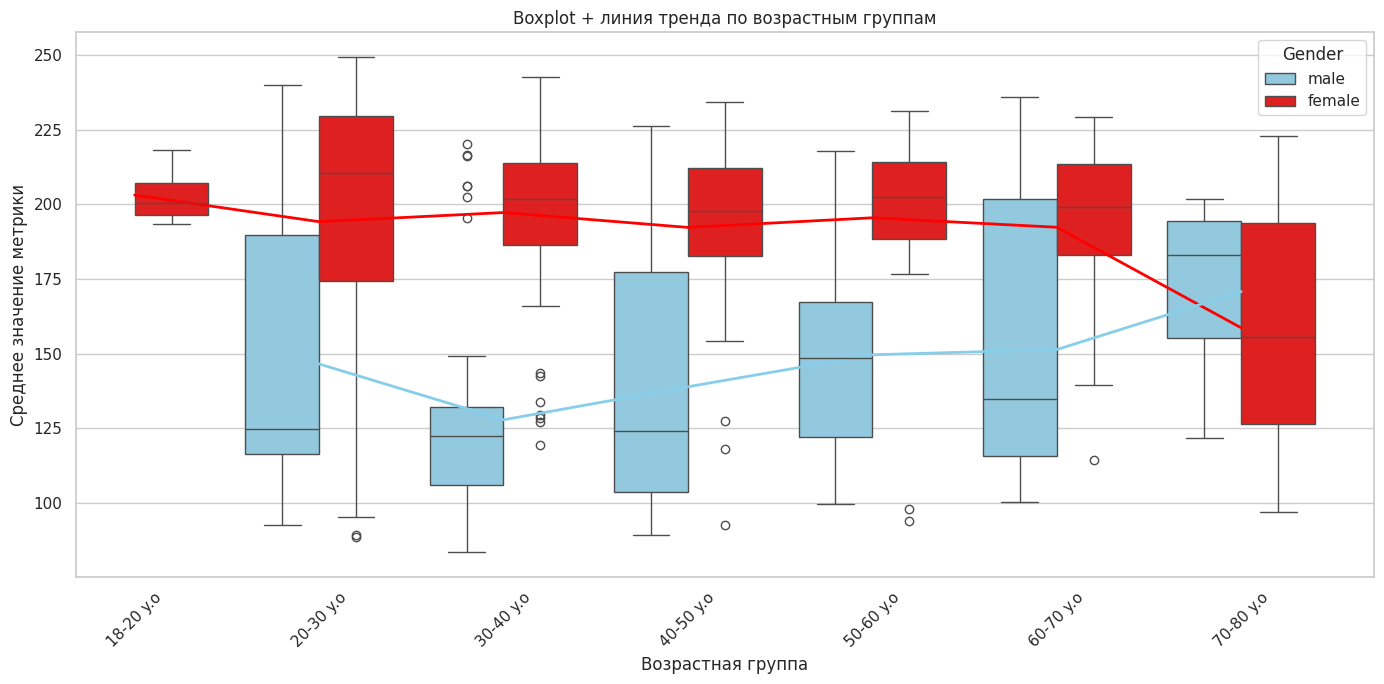

In [ ]:


sns.set(style="whitegrid")

metric = "f0_median"

# усреднение по группам (для линии тренда)
trend = df.groupby(["age_group", "gender"])[metric].mean().reset_index()

plt.figure(figsize=(14, 7))

# ---------------------------
# 1. BOXPLOT
# ---------------------------
sns.boxplot(
    data=df,
    x="age_group",
    y=metric,
    hue="gender",
    palette={"female": "red", "male": "skyblue"}
)

# ---------------------------
# 2. LINE TREND
# ---------------------------
for gender, color in [("female", "red"), ("male", "skyblue")]:
    temp = trend[trend["gender"] == gender].sort_values("age_group")

    plt.plot(
        temp["age_group"],
        temp[metric],
        linewidth=2,
        color=color
    )

plt.title("Boxplot + линия тренда по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Среднее значение метрики")
plt.xticks(rotation=45)

plt.legend(title = "Gender")
plt.tight_layout()
plt.show()

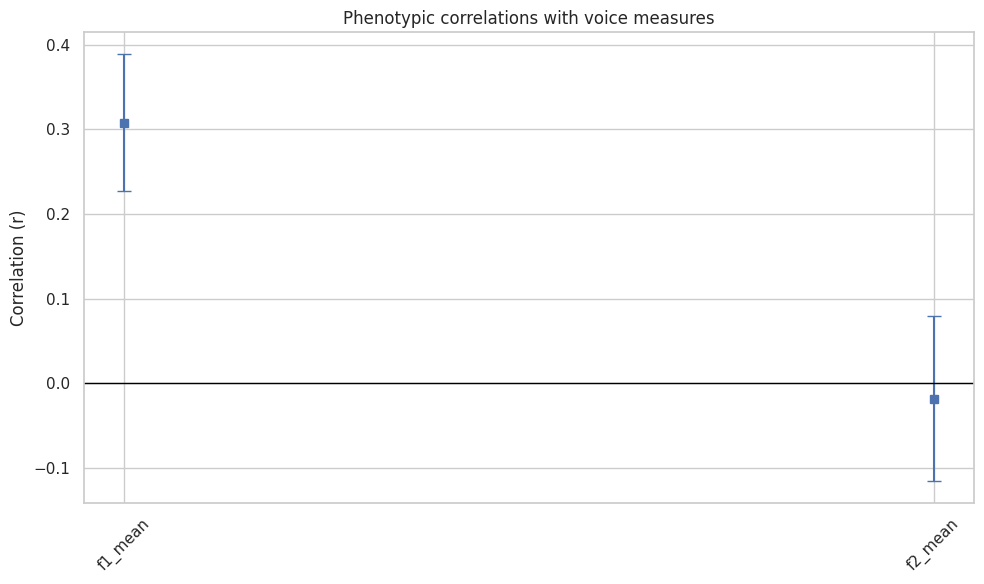

In [41]:
import numpy as np
from scipy.stats import pearsonr

def bootstrap_corr_ci(x, y, n_boot=1000):
    vals = []
    n = len(x)

    for _ in range(n_boot):
        idx = np.random.randint(0, n, n)

        if np.std(x[idx]) == 0 or np.std(y[idx]) == 0:
            continue

        r, _ = pearsonr(x[idx], y[idx])
        vals.append(r)

    ci_low = np.percentile(vals, 2.5)
    ci_high = np.percentile(vals, 97.5)
    r_mean = np.mean(vals)

    return r_mean, ci_low, ci_high


target = "f0_median"
phenotypes = ["f1_mean", "f2_mean"]

results = []

for ph in phenotypes:
    x = df[target].values
    y = df[ph].values

    r_mean, ci_low, ci_high = bootstrap_corr_ci(x, y)

    results.append([ph, r_mean, ci_low, ci_high])

corr_df = pd.DataFrame(results, columns=["phenotype", "r", "ci_low", "ci_high"])

alpha = 0.05
corr_df["bonferroni"] = alpha / len(phenotypes)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.errorbar(
    corr_df["phenotype"],
    corr_df["r"],
    yerr=[
        corr_df["r"] - corr_df["ci_low"],
        corr_df["ci_high"] - corr_df["r"]
    ],
    fmt="s",
    capsize=5
)

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=45)
plt.ylabel("Correlation (r)")
plt.title("Phenotypic correlations with voice measures")

plt.tight_layout()
plt.show()